# Downloading necessary packages

In [ ]:
!pip install opendatasets

# Downloading the dataset

In [ ]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/brjapon/cwru-bearing-datasets')

Skipping, found downloaded files in "./cwru-bearing-datasets" (use force=True to force download)


# Reading the dataset

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/cwru-bearing-datasets/feature_time_48k_2048_load_1.csv")
df.head(10)

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1
5,0.43726,-0.44435,0.021119,0.138763,0.140328,-0.131329,-0.168557,3.115990,6.644538,Ball_007_1
6,0.45353,-0.49129,0.021464,0.138461,0.140082,-0.114175,0.308107,3.237609,6.526352,Ball_007_1
7,0.43955,-0.45228,0.020860,0.150120,0.151526,-0.021955,-0.272298,2.900820,7.263885,Ball_007_1
8,0.49233,-0.37217,0.020244,0.145361,0.146729,0.074174,-0.421814,3.355377,7.248013,Ball_007_1
9,0.37154,-0.49087,0.018105,0.136393,0.137556,-0.136237,-0.097889,2.701005,7.597902,Ball_007_1


In [ ]:
df.count()

,0
max,2300
min,2300
mean,2300
sd,2300
rms,2300
skewness,2300
kurtosis,2300
crest,2300
form,2300
fault,2300


# Preprocessing the data

In [ ]:
df.isnull().sum()

,0
max,0
min,0
mean,0
sd,0
rms,0
skewness,0
kurtosis,0
crest,0
form,0
fault,0


In [ ]:
df['fault'].unique()

array(['Ball_007_1', 'Ball_014_1', 'Ball_021_1', 'IR_007_1', 'IR_014_1',
       'IR_021_1', 'OR_007_6_1', 'OR_014_6_1', 'OR_021_6_1', 'Normal_1'],
      dtype=object)

In [ ]:
df['fault'].nunique()

10

In [ ]:
df['fault'].value_counts()

,count
fault,
Ball_007_1,230
Ball_014_1,230
Ball_021_1,230
IR_007_1,230
IR_014_1,230
IR_021_1,230
OR_007_6_1,230
OR_014_6_1,230
OR_021_6_1,230


In [ ]:
df_updated = df[:2070]
df_updated.tail()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
2065,2.7527,-2.8629,0.014965,0.418131,0.418297,-0.553010,12.676896,6.580735,27.951915,OR_021_6_1
2066,3.9655,-4.7267,0.016207,0.700782,0.700798,-0.373075,10.042316,5.658545,43.240366,OR_021_6_1
2067,5.0472,-5.2876,0.013215,0.649890,0.649866,-0.754219,23.502285,7.766529,49.177013,OR_021_6_1
2068,4.2276,-3.9680,0.013392,0.629442,0.629431,0.168071,10.860176,6.716542,47.001398,OR_021_6_1
2069,2.6851,-3.1175,0.013094,0.442665,0.442751,-0.785906,14.589774,6.064584,33.814099,OR_021_6_1


In [ ]:
df_updated.count()

,0
max,2070
min,2070
mean,2070
sd,2070
rms,2070
skewness,2070
kurtosis,2070
crest,2070
form,2070
fault,2070


In [ ]:
df_updated[1000:1500]

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
1000,1.05180,-1.07540,0.032248,0.232204,0.234376,-0.080995,1.970433,4.487659,7.267819,IR_014_1
1001,0.85950,-0.67404,0.031814,0.178095,0.180871,0.058375,1.192386,4.752008,5.685286,IR_014_1
1002,0.84614,-0.76103,0.031494,0.187887,0.190463,0.141306,1.152323,4.442544,6.047597,IR_014_1
1003,0.73349,-0.66173,0.032701,0.188549,0.191319,-0.109808,1.009511,3.833864,5.850594,IR_014_1
1004,1.36370,-1.05660,0.029780,0.239937,0.241720,0.194076,2.321255,5.641663,8.116790,IR_014_1
...,...,...,...,...,...,...,...,...,...,...
1495,5.06480,-4.91910,0.011702,1.028213,1.028029,0.053094,4.778169,4.926710,87.850014,OR_007_6_1
1496,5.08560,-5.06100,0.008949,1.087016,1.086788,0.115486,3.889475,4.679479,121.435599,OR_007_6_1
1497,4.58070,-4.85020,0.012165,1.115891,1.115685,0.039799,3.137767,4.105728,91.716110,OR_007_6_1
1498,4.90910,-4.80430,0.009937,1.056557,1.056346,0.085648,4.306104,4.647247,106.308612,OR_007_6_1


In [ ]:
fault_mapping = {
    "Ball_007_1":"cage",
    "Ball_014_1":"cage",
    "Ball_021_1":"cage",
    "OR_007_6_1":"Outer_race",
    "OR_014_6_1":"Outer_race",
    "OR_021_6_1":"Outer_race",
    "IR_007_1":"Inner_race",
    "IR_014_1":"Inner_race",
    "IR_021_1":"Inner_race"
}

df_updated.loc[:, 'fault'] = df_updated['fault'].map(fault_mapping)

In [ ]:
df_updated['fault'].unique()

array(['cage', 'Inner_race', 'Outer_race'], dtype=object)

In [ ]:
x = df_updated.drop('fault', axis=1)
y = df_updated['fault']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train.head()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form
849,1.56190,-1.30160,0.020809,0.282832,0.283528,-0.259899,4.263335,5.508806,13.625015
1043,0.93063,-0.86075,0.029995,0.207779,0.209883,0.024137,0.961147,4.434051,6.997215
175,0.46375,-0.42057,0.019353,0.135218,0.136564,0.118142,0.102196,3.395854,7.056585
1228,2.89330,-3.11420,0.012194,0.662103,0.662054,-0.022002,2.257049,4.370189,54.291670
538,0.67654,-0.68780,0.014420,0.222565,0.222978,-0.022632,-0.047582,3.034115,15.463407


In [ ]:
x_test.head()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form
1181,2.30940,-2.22800,0.012276,0.602560,0.602538,0.027124,0.670321,3.832786,49.083218
69,0.52905,-0.44080,0.018347,0.141655,0.142804,0.105538,0.054435,3.704717,7.783371
351,2.31600,-1.83960,0.010017,0.337542,0.337609,0.411260,11.179409,6.860014,33.702434
1163,1.74720,-1.89900,0.007350,0.564243,0.564153,0.024943,0.112674,3.097034,76.754246
429,0.57724,-0.51465,0.009112,0.148539,0.148782,-0.031814,1.285671,3.879764,16.328111


In [ ]:
y_train.head()

,fault
849,Inner_race
1043,Inner_race
175,cage
1228,Inner_race
538,cage


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

print(f"Encoded labels: {y_train_encoded}")
print(f"Mapping: {dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))}")

Encoded labels: [0 0 2 ... 0 0 0]
Mapping: {'Inner_race': np.int64(0), 'Outer_race': np.int64(1), 'cage': np.int64(2)}


# Training

## 1. Random Forest classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(x_train_scaled, y_train_encoded)

RandomForestClassifier(random_state=42)

## 2. SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(x_train_scaled, y_train_encoded)

SVC(kernel='linear', random_state=42)

## 3. KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train_encoded)

KNeighborsClassifier()

#Testing

## 1. Random Forest Classifier

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = random_forest_model.predict(x_test_scaled)

print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       127
           1       0.98      0.96      0.97       142
           2       0.96      0.97      0.97       145

    accuracy                           0.98       414
   macro avg       0.98      0.98      0.98       414
weighted avg       0.98      0.98      0.98       414



In [ ]:
import pandas as pd

y_pred = random_forest_model.predict(x_test_scaled)

analysis_df = pd.DataFrame({
    'rms': x_test_scaled[:, 0],
    'skew': x_test_scaled[:, 1],
    'is_correct': (y_pred == y_test)
})

rms_correct = analysis_df[analysis_df['is_correct'] == True]['rms']
skew_correct = analysis_df[analysis_df['is_correct'] == True]['skew']

rms_incorrect = analysis_df[analysis_df['is_correct'] == False]['rms']
skew_incorrect = analysis_df[analysis_df['is_correct'] == False]['skew']

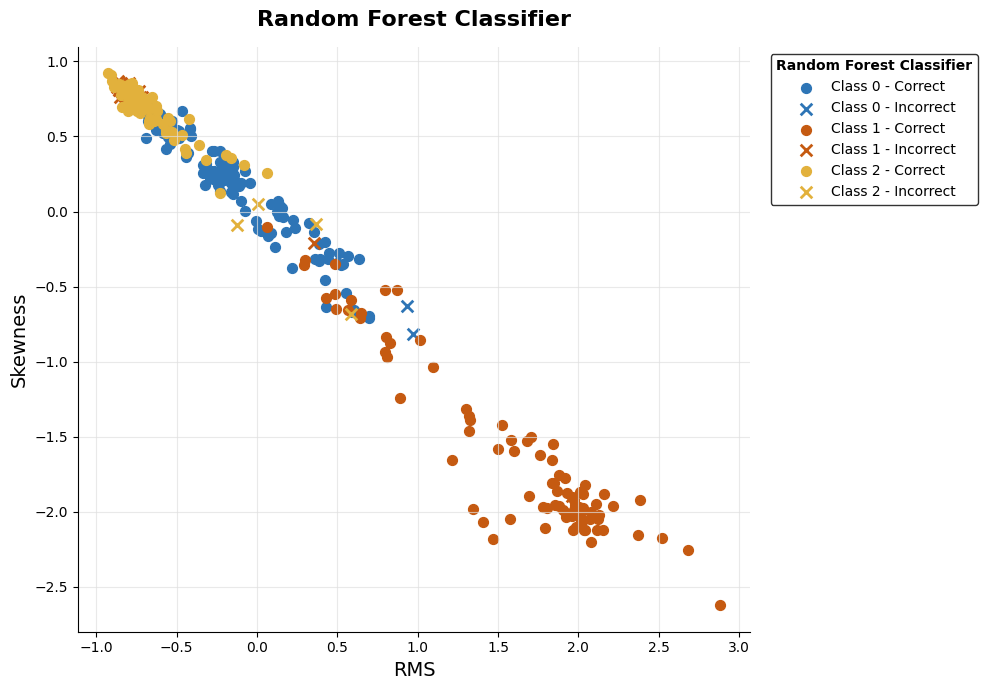

In [ ]:
import numpy as np

y_pred = svm_model.predict(x_test_scaled)
is_correct = (y_pred == y_test_encoded)

class_colors = {
    0: '#2e75b6',
    1: '#c55a11',
    2: '#e2b13c'
}

plt.figure(figsize=(10, 7), facecolor='white')

for class_id in range(3):
    class_mask = (y_test_encoded == class_id)
    color = class_colors[class_id]

    mask_c = class_mask & is_correct
    if np.any(mask_c):
        plt.scatter(x_test_scaled[mask_c, 0], x_test_scaled[mask_c, 1],
                    c=color, marker='o', s=50, label=f'Class {class_id} - Correct')

    mask_i = class_mask & ~is_correct
    if np.any(mask_i):
        plt.scatter(x_test_scaled[mask_i, 0], x_test_scaled[mask_i, 1],
                    c=color, marker='x', s=70, linewidths=2, label=f'Class {class_id} - Incorrect')

plt.title('Random Forest Classifier', fontweight='bold', fontsize=16, pad=15)
plt.xlabel('RMS', fontsize=14)
plt.ylabel('Skewness', fontsize=14)

plt.grid(True, linestyle='-', color='#e0e0e0', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(title='Random Forest Classifier',
           bbox_to_anchor=(1.02, 1),
           loc='upper left',
           frameon=True,
           edgecolor='black',
           title_fontproperties={'weight': 'bold'})

plt.tight_layout()
plt.savefig('random_forest_classification_results.png')
plt.show()

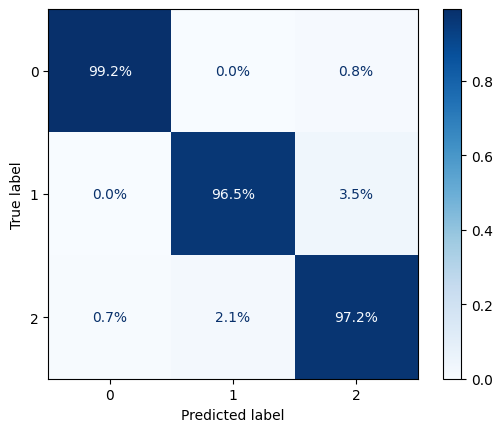

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_encoded, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
disp.plot(cmap=plt.cm.Blues, values_format='.1%')
plt.show()

## 2. SVM

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = svm_model.predict(x_test_scaled)

print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       127
           1       0.96      0.63      0.76       142
           2       0.74      0.97      0.84       145

    accuracy                           0.86       414
   macro avg       0.89      0.86      0.86       414
weighted avg       0.88      0.86      0.86       414



In [ ]:
import pandas as pd

y_pred = svm_model.predict(x_test_scaled)

analysis_df = pd.DataFrame({
    'rms': x_test_scaled[:, 0],
    'skew': x_test_scaled[:, 1],
    'is_correct': (y_pred == y_test)
})

rms_correct = analysis_df[analysis_df['is_correct'] == True]['rms']
skew_correct = analysis_df[analysis_df['is_correct'] == True]['skew']

rms_incorrect = analysis_df[analysis_df['is_correct'] == False]['rms']
skew_incorrect = analysis_df[analysis_df['is_correct'] == False]['skew']

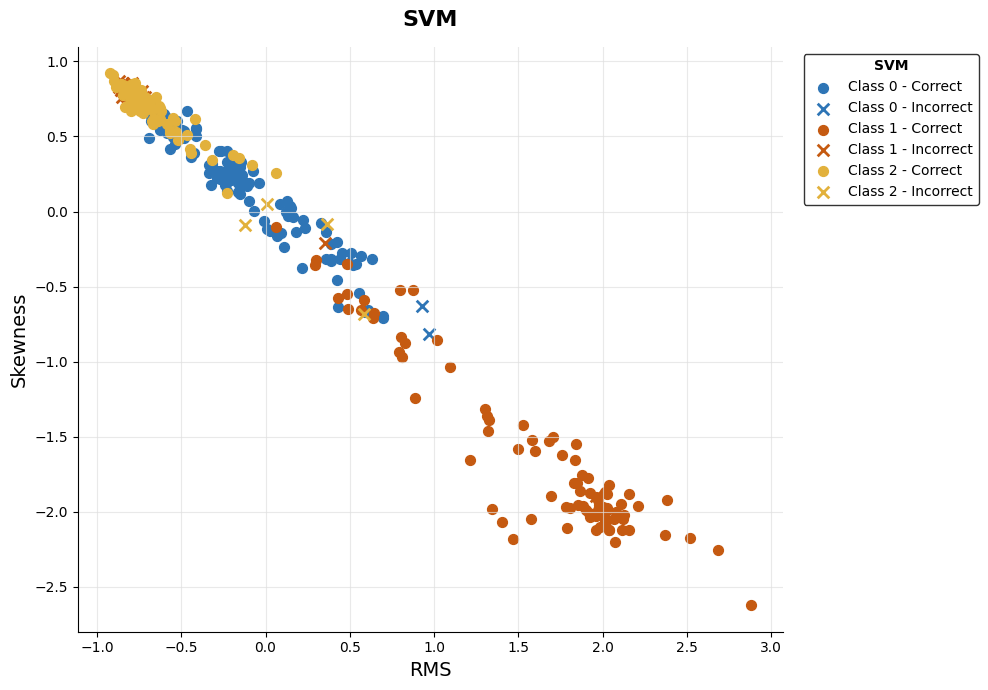

In [ ]:
import numpy as np

y_pred = svm_model.predict(x_test_scaled)
is_correct = (y_pred == y_test_encoded)

class_colors = {
    0: '#2e75b6',
    1: '#c55a11',
    2: '#e2b13c'
}

plt.figure(figsize=(10, 7), facecolor='white')

for class_id in range(3):
    class_mask = (y_test_encoded == class_id)
    color = class_colors[class_id]

    mask_c = class_mask & is_correct
    if np.any(mask_c):
        plt.scatter(x_test_scaled[mask_c, 0], x_test_scaled[mask_c, 1],
                    c=color, marker='o', s=50, label=f'Class {class_id} - Correct')

    mask_i = class_mask & ~is_correct
    if np.any(mask_i):
        plt.scatter(x_test_scaled[mask_i, 0], x_test_scaled[mask_i, 1],
                    c=color, marker='x', s=70, linewidths=2, label=f'Class {class_id} - Incorrect')

plt.title('SVM', fontweight='bold', fontsize=16, pad=15)
plt.xlabel('RMS', fontsize=14)
plt.ylabel('Skewness', fontsize=14)

plt.grid(True, linestyle='-', color='#e0e0e0', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(title='SVM',
           bbox_to_anchor=(1.02, 1),
           loc='upper left',
           frameon=True,
           edgecolor='black',
           title_fontproperties={'weight': 'bold'})

plt.tight_layout()
plt.savefig('svm_classification_results.png')
plt.show()

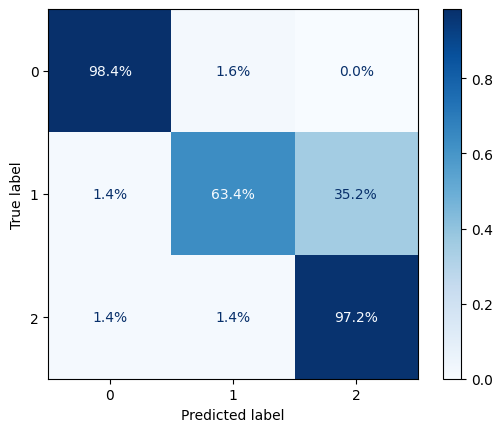

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_encoded, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
disp.plot(cmap=plt.cm.Blues, values_format='.1%')
plt.show()

## 3. KNN

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = knn_model.predict(x_test_scaled)

print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       127
           1       0.88      0.91      0.89       142
           2       0.90      0.86      0.88       145

    accuracy                           0.92       414
   macro avg       0.92      0.92      0.92       414
weighted avg       0.92      0.92      0.92       414



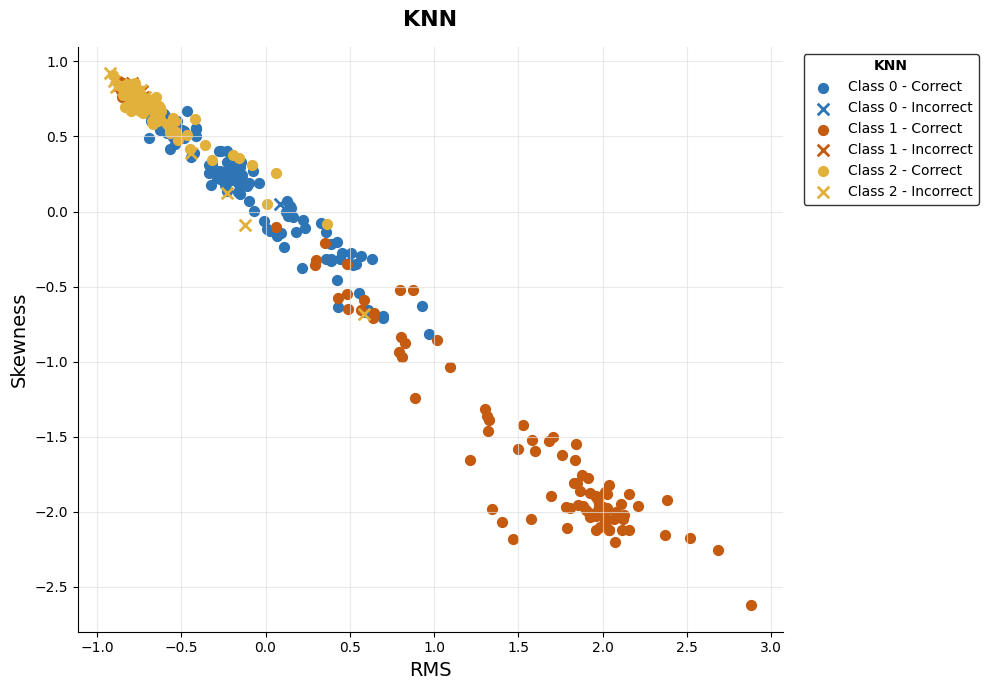

In [ ]:
import numpy as np

y_pred = knn_model.predict(x_test_scaled)
is_correct = (y_pred == y_test_encoded)

class_colors = {
    0: '#2e75b6',
    1: '#c55a11',
    2: '#e2b13c'
}

plt.figure(figsize=(10, 7), facecolor='white')

for class_id in range(3):
    class_mask = (y_test_encoded == class_id)
    color = class_colors[class_id]

    mask_c = class_mask & is_correct
    if np.any(mask_c):
        plt.scatter(x_test_scaled[mask_c, 0], x_test_scaled[mask_c, 1],
                    c=color, marker='o', s=50, label=f'Class {class_id} - Correct')

    mask_i = class_mask & ~is_correct
    if np.any(mask_i):
        plt.scatter(x_test_scaled[mask_i, 0], x_test_scaled[mask_i, 1],
                    c=color, marker='x', s=70, linewidths=2, label=f'Class {class_id} - Incorrect')

plt.title('KNN', fontweight='bold', fontsize=16, pad=15)
plt.xlabel('RMS', fontsize=14)
plt.ylabel('Skewness', fontsize=14)

plt.grid(True, linestyle='-', color='#e0e0e0', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend(title='KNN',
           bbox_to_anchor=(1.02, 1),
           loc='upper left',
           frameon=True,
           edgecolor='black',
           title_fontproperties={'weight': 'bold'})

plt.tight_layout()
plt.savefig('knn_classification_results.png')
plt.show()

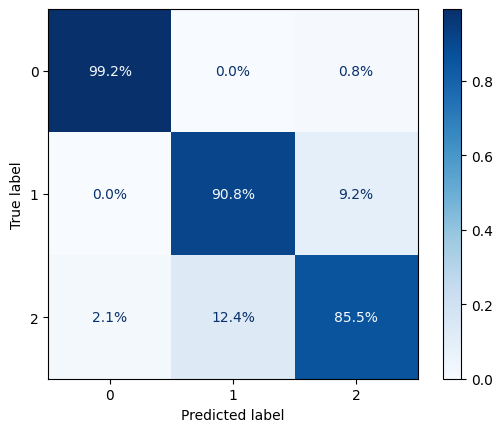

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_encoded, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
disp.plot(cmap=plt.cm.Blues, values_format='.1%')
plt.show()

# downloading the model

In [ ]:
import pickle

with open('random_forest_model.pkl', 'wb') as model_file:
    pickle.dump(random_forest_model, model_file)